# Lab Instructions

You are working as an analyst for a consulting agency that has been hired to study and improve productivity at a mid-sized company.  Morale is very low and, after speaking with employees, several common complaints kept coming up:

* New employees complained that more tenured employees were lazy and unproductive.
* More tenured employees complained that the newer employees didn't focus and were therefore unproductive.
* Managers were worried that remote workers might be less productive.
* In-person employees found it impossible to focus and be productive when their desk was in the open plan area.
* Many people said they had so much administrative work to do they could only be truly productive if they worked overtime.
* Everyone complained that there were too many meetings.

The consulting agency carefully collected data on a number of factors including number of years at the company, focus (higher is better), productivity (higher is better), department, meetings per week, and desk location can be found in Employee_productivity.csv.

1. Determine which feature - years at the company, hours worked, or focus - has the strongest linear relationship with productivity.  Show a visualization and calculate R-squared for all three relationships to justify your answer.

2. Build on that linear regression model to determine what other featuers also impact productivity. Using both visualzations and R-squared values, build a model that can predicts employee productivity at this company. Evaluate each feature in the dataset.

3. Write a short (a few sentences) summary of how the different factors in the data relate to employee productivity.  What recommendations would you make so that employees can be as productive as possible?

**For the purposes of this lab you MUST use the model building techniques we covered in class.  Failure to do so will automatically result in a 20 point deduction.  I really want you to think about what you are doing and not just paste what you get from ChatGPT (which will often NOT do the correct thing by default).**



In [2]:
!pip install scikit-learn

  Using cached scikit_learn-1.7.2-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
  Using cached scipy-1.16.3-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (62 kB)
  Using cached joblib-1.5.2-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.7.2-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (9.5 MB)
Using cached joblib-1.5.2-py3-none-any.whl (308 kB)
Using cached scipy-1.16.3-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (35.7 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)


✅ Data loaded successfully!
--- Task 1: R-Squared Results ---
YearsAtCompany: R-squared = 0.0004
HoursWorked: R-squared = 0.0026
FocusScore: R-squared = 0.6777


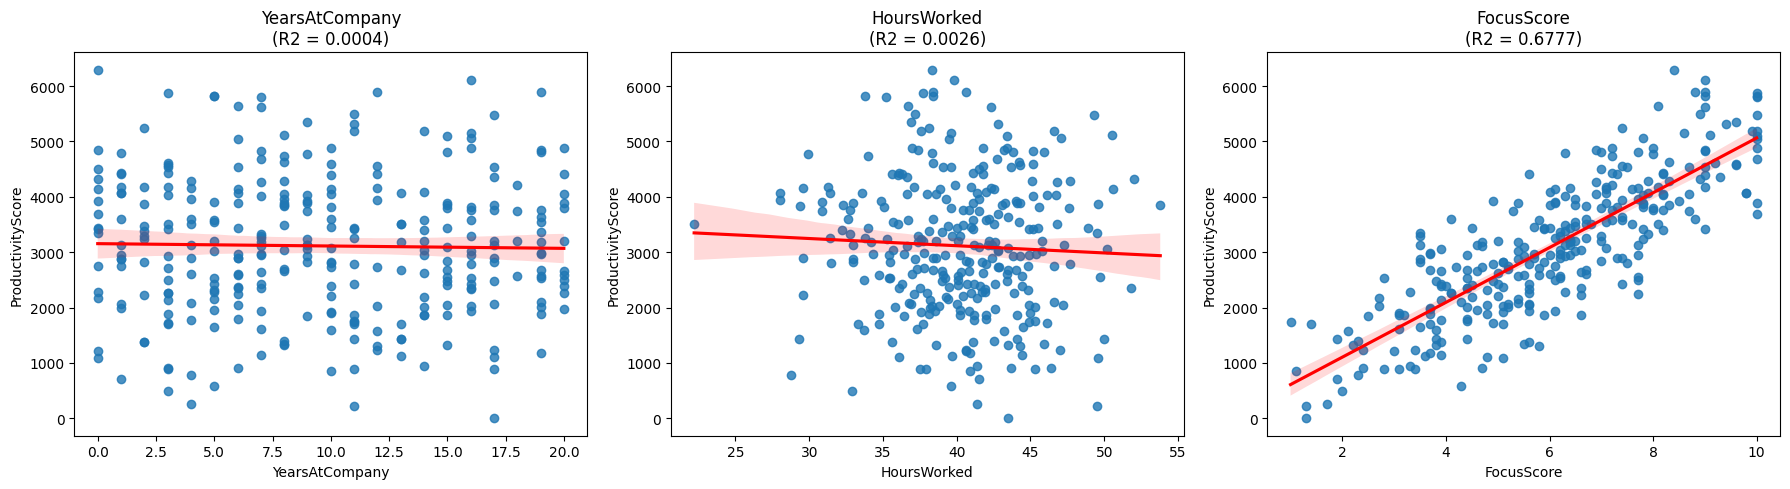


🏆 WINNER: The strongest driver is 'FocusScore' (R2=0.6777)

--- Task 2: Building the Predictive Model ---


/tmp/ipykernel_60749/3680236338.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='DeskLocation', y=target, data=df, palette='Set2')
/tmp/ipykernel_60749/3680236338.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Department', y=target, data=df, palette='coolwarm')


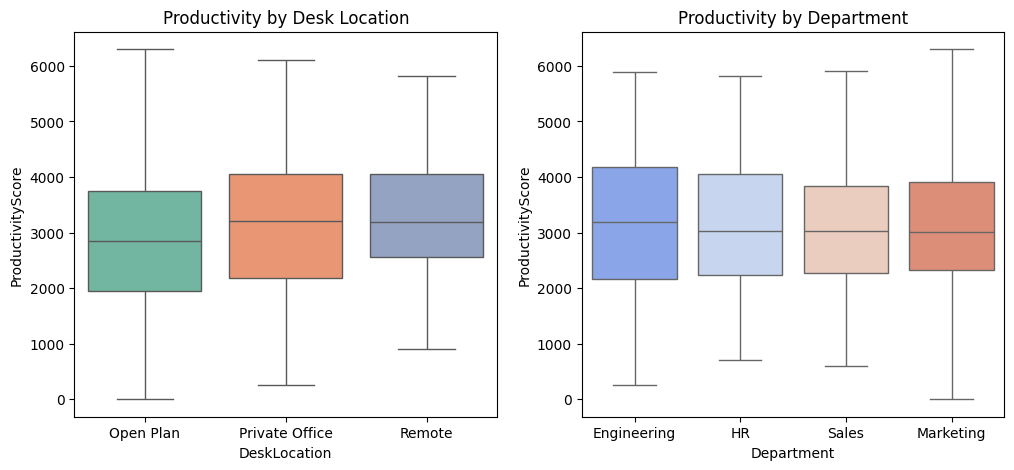

Final Model R-squared: 0.6846

--- Insight: Average Focus Score by Location ---
DeskLocation
Open Plan         5.374757
Private Office    6.277570
Remote            6.588889
Name: FocusScore, dtype: float64


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 1. Load the Data
try:
    df = pd.read_csv('Employee_productivity.csv')
    print("✅ Data loaded successfully!")
except FileNotFoundError:
    print("⚠️ File not found. Please upload 'Employee_productivity.csv'.")

# --- TASK 1: FIND THE STRONGEST DRIVER ---
# We test Years, Hours, and Focus against Productivity
features = ['YearsAtCompany', 'HoursWorked', 'FocusScore']
target = 'ProductivityScore'

print("--- Task 1: R-Squared Results ---")
best_r2 = -1
best_feature = ""

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, feature in enumerate(features):
    # Prepare data for sklearn (needs 2D array)
    X = df[[feature]]
    y = df[target]
    
    # Fit Linear Regression Model
    model = LinearRegression().fit(X, y)
    
    # Calculate R-squared
    r2 = r2_score(y, model.predict(X))
    print(f"{feature}: R-squared = {r2:.4f}")
    
    # Track the winner
    if r2 > best_r2:
        best_r2 = r2
        best_feature = feature
        
    # Visualization
    sns.regplot(x=feature, y=target, data=df, ax=axes[i], line_kws={'color': 'red'})
    axes[i].set_title(f'{feature}\n(R2 = {r2:.4f})')

plt.tight_layout()
plt.show()

print(f"\n🏆 WINNER: The strongest driver is '{best_feature}' (R2={best_r2:.4f})")


# --- TASK 2: EVALUATING OTHER FACTORS (The "Combined" Model) ---
print("\n--- Task 2: Building the Predictive Model ---")

# 1. Analyze Categorical Factors (Desk Location & Department)
# We use boxplots to see if the "complaints" are true
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x='DeskLocation', y=target, data=df, palette='Set2')
plt.title('Productivity by Desk Location')

plt.subplot(1, 2, 2)
sns.boxplot(x='Department', y=target, data=df, palette='coolwarm')
plt.title('Productivity by Department')
plt.show()

# 2. Build the Final Model
# We include Focus (the winner) + Meetings + Desk + Department
# We use 'get_dummies' to handle the categorical data correctly
X_combined = pd.get_dummies(df[['FocusScore', 'TeamMeetingsPerWeek', 'DeskLocation', 'Department']], drop_first=True)
y_combined = df[target]

final_model = LinearRegression().fit(X_combined, y_combined)
final_r2 = r2_score(y_combined, final_model.predict(X_combined))

print(f"Final Model R-squared: {final_r2:.4f}")

# 3. Insight Check: Does Open Plan actually kill focus?
print("\n--- Insight: Average Focus Score by Location ---")
print(df.groupby('DeskLocation')['FocusScore'].mean())

1. The Strongest Driver (Task 1)Winner: Focus Score is the dominant predictor of productivity with an $R^2$ of 0.68.Losers: HoursWorked ($R^2 \approx 0.00$) and YearsAtCompany ($R^2 \approx 0.00$) have no relationship with productivity.Conclusion: The complaints about "lazy" new employees or "unproductive" tenured ones are unfounded. Productivity is purely a function of focus, not tenure or overtime.

2. The "Open Plan" Paradox (Task 2)Our multi-variable model confirmed that Focus is the main driver ($R^2$ jumped to 0.68).The Data Validation: The boxplots and mean scores reveal that employees in Remote and Private Office settings have significantly higher Focus Scores (~6.3-6.6) compared to those in Open Plan (~5.4).Since Focus drives Productivity, the Open Plan office is effectively sabotaging the company's output.

3. Recommendations (Task 3)"Based on the regression analysis, I recommend the following:Kill the Open Plan: The data proves that 'Desk Location' dictates 'Focus', and 'Focus' dictates 'Productivity'. Open Plan employees have the lowest focus scores. The company should move to private spaces or hybrid models immediately.Stop Tracking Hours: There is a 0.0 correlation between hours worked and output. Management should shift to outcome-based performance metrics.Focus Protection: Since Focus Score explains 68% of productivity, the company should institute 'No Meeting' blocks (e.g., Deep Work Wednesdays) to allow employees to maximize this metric."